In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA = PROJECT_DIR / "processed" / "cleaned_dataset.csv"

df = pd.read_csv(DATA)

print(df.shape)

df.head()

(23424, 48)


,Week,Measurement_Site,Latitude,Longitude,Source_File,Vehicle_Category,Time,von Unten nach Oben,von Links nach Oben,von Links nach Unten,von Oben nach Unten,Fahrtrichtung Süd-West,Fahrtrichtung Nord-Ost,Fahrtrichtung Nord-West,Fahrtrichtung Süd-Ost,Fahrtrichtung Nord-Ost.1,Fahrtrichtung Süd-West.1,von Rechts nach Unten,von Rechts nach Oben,Von Links nach Oben,Von Links nach Unten,Von Oben nach Unten,Fahrtrichtung Süd,Fahrtrichtung Nord,Fahrtrichtung West,Fahrtrichtung Ost,Leicht-rechts in Links,Rechts in Oben,Geradeaus in Links,Rechts in Oben.1,Falschfahrer,Falschfahrer.1,Falschfahrer.2,Geradeaus in Unten,Geradeaus in Oben,Fahrtrichtung Nord.1,Fahrtrichtung Süd.1,von Rechts Links nach Unten,von Links Geradeaus in Rechts,von Oben Links in Rechts,von Oben Geradeaus in Unten,von Unten Geradeaus in Oben,nach Unten,Total_Traffic,Hour,Minute,Peak_Period,Time_Interval
0,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,Off Peak,00:00
1,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,15,Off Peak,00:15
2,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,30,Off Peak,00:30
3,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:45:00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0,45,Off Peak,00:45
4,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 01:00:00,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1,0,Off Peak,01:00


In [3]:
print("="*60)

print("Measurement Sites")

print("="*60)

print(df["Measurement_Site"].unique())

Measurement Sites
<ArrowStringArray>
[       'Glauburgstraße',    'Hanauer Landstraße',           'Töngesgasse',
                   'B44',    'Habsburgerallee 59',      'Heiligkreuzgasse',
 'Mainzer Landstraße 32',       'Friedberger Tor', 'Max Horkheimer Str. 2',
       'Mercatorstr. 37', 'Richard Wagner Straße']
Length: 11, dtype: str


In [4]:
overall = (

    df

    .groupby("Measurement_Site")["Total_Traffic"]

    .sum()

    .sort_values(ascending=False)

)

overall

Measurement_Site
B44                      557154.0
Mainzer Landstraße 32    361342.0
Friedberger Tor          350811.0
Hanauer Landstraße       228414.0
Richard Wagner Straße    185420.0
Glauburgstraße           105174.0
Habsburgerallee 59        78837.0
Töngesgasse               67545.0
Heiligkreuzgasse          21417.0
Max Horkheimer Str. 2      5940.0
Mercatorstr. 37            5352.0
Name: Total_Traffic, dtype: float64

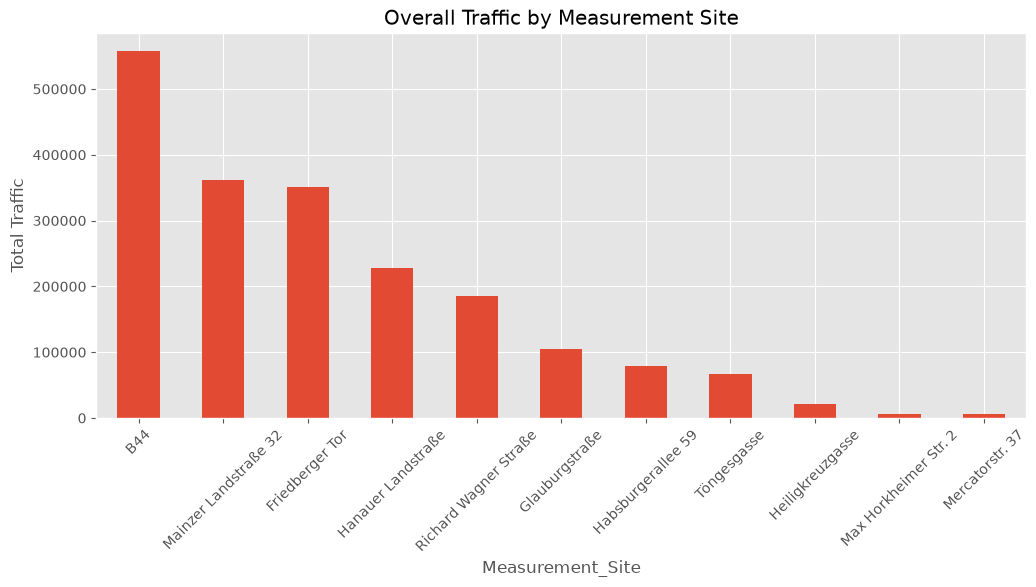

In [5]:
plt.figure(figsize=(12,5))

overall.plot(kind="bar")

plt.ylabel("Total Traffic")

plt.title("Overall Traffic by Measurement Site")

plt.xticks(rotation=45)

plt.show()

In [6]:
average = (

    df

    .groupby("Measurement_Site")["Total_Traffic"]

    .mean()

    .sort_values(ascending=False)

)

average

Measurement_Site
B44                      290.184375
Mainzer Landstraße 32    188.198958
Friedberger Tor          166.103693
Richard Wagner Straße    107.303241
Hanauer Landstraße        54.075284
Glauburgstraße            49.798295
Habsburgerallee 59        41.060938
Töngesgasse               31.981534
Heiligkreuzgasse          11.154687
Max Horkheimer Str. 2      3.437500
Mercatorstr. 37            3.097222
Name: Total_Traffic, dtype: float64

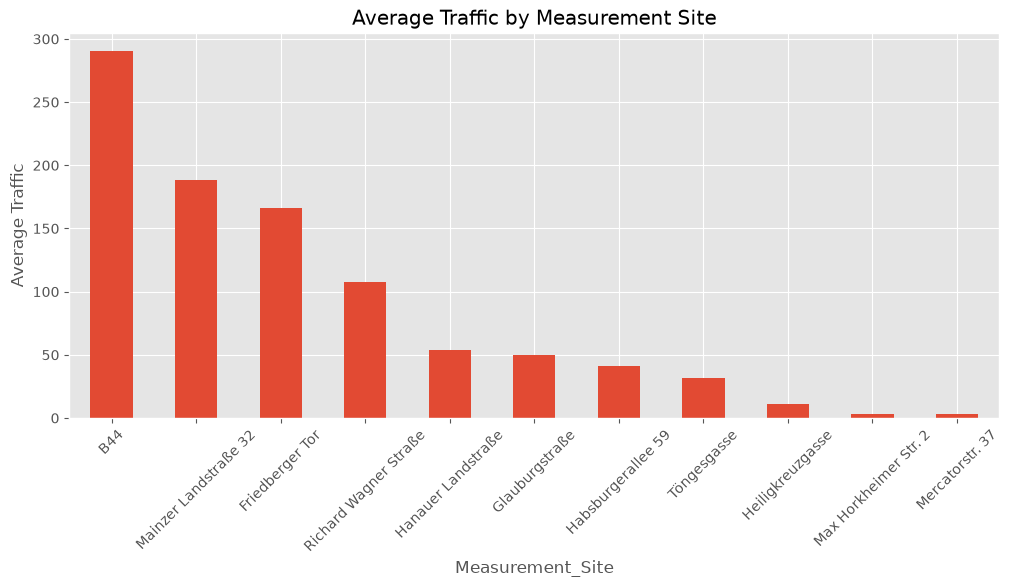

In [7]:
plt.figure(figsize=(12,5))

average.plot(kind="bar")

plt.ylabel("Average Traffic")

plt.title("Average Traffic by Measurement Site")

plt.xticks(rotation=45)

plt.show()

In [8]:
peak = (

    df

    .groupby("Measurement_Site")["Total_Traffic"]

    .max()

    .sort_values(ascending=False)

)

peak

Measurement_Site
B44                      2292.0
Mainzer Landstraße 32    1788.0
Friedberger Tor          1199.0
Richard Wagner Straße     932.0
Hanauer Landstraße        513.0
Glauburgstraße            465.0
Habsburgerallee 59        330.0
Töngesgasse               330.0
Max Horkheimer Str. 2     210.0
Heiligkreuzgasse          114.0
Mercatorstr. 37            54.0
Name: Total_Traffic, dtype: float64

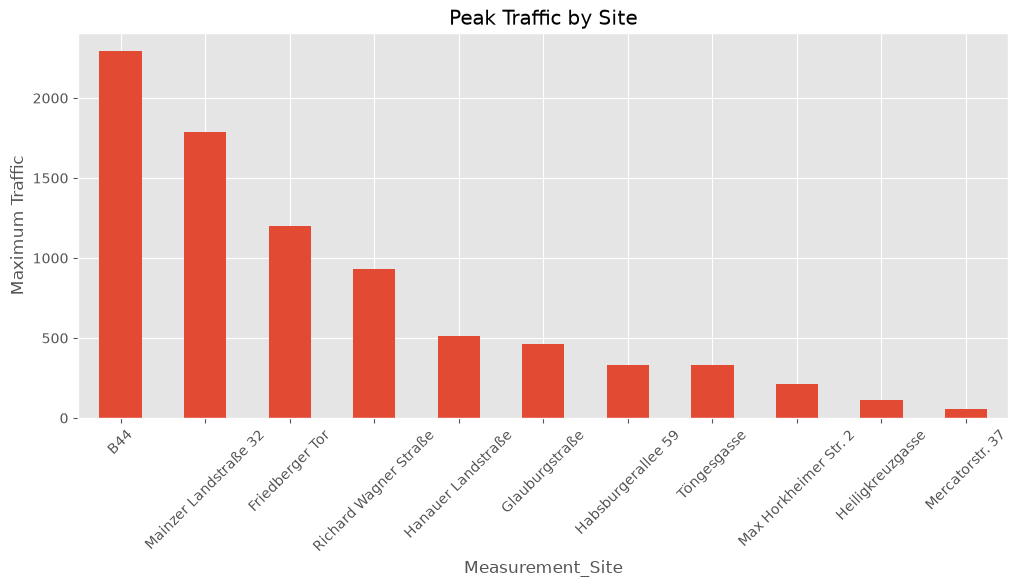

In [9]:
plt.figure(figsize=(12,5))

peak.plot(kind="bar")

plt.ylabel("Maximum Traffic")

plt.title("Peak Traffic by Site")

plt.xticks(rotation=45)

plt.show()

In [10]:
hourly = (

    df

    .groupby(

        [

            "Measurement_Site",

            "Hour"

        ]

    )

    ["Total_Traffic"]

    .mean()

    .reset_index()

)

hourly.head()

,Measurement_Site,Hour,Total_Traffic
0,B44,0,37.0875
1,B44,1,18.2250
2,B44,2,15.4875
3,B44,3,14.9250
4,B44,4,16.4625


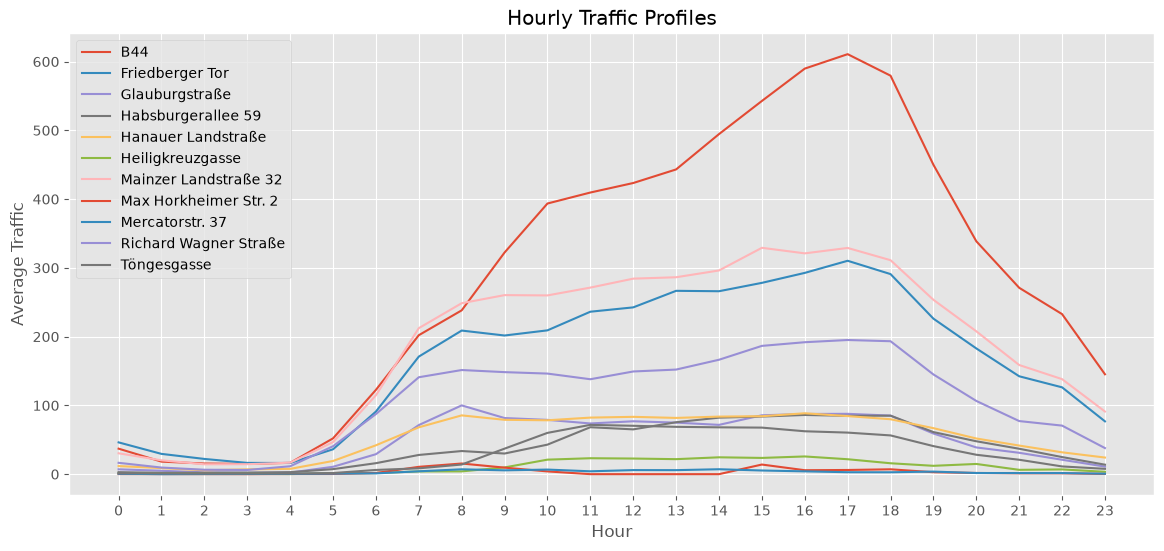

In [11]:
plt.figure(figsize=(14,6))

for site in hourly["Measurement_Site"].unique():

    temp = hourly[
        hourly["Measurement_Site"] == site
    ]

    plt.plot(

        temp["Hour"],

        temp["Total_Traffic"],

        label=site

    )

plt.legend()

plt.xticks(range(24))

plt.xlabel("Hour")

plt.ylabel("Average Traffic")

plt.title("Hourly Traffic Profiles")

plt.show()

In [12]:
heatmap = pd.pivot_table(

    df,

    values="Total_Traffic",

    index="Measurement_Site",

    columns="Hour",

    aggfunc="mean"

)

heatmap

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Measurement_Site,,,,,,,,,,,,,,,,,,,,,,,,
B44,37.087500,18.225000,15.487500,14.925000,16.462500,52.050000,122.587500,202.087500,238.237500,322.350000,393.600000,409.575000,423.412500,443.175000,494.550000,542.737500,589.800000,610.800000,579.525000,449.962500,338.700000,271.050000,232.762500,145.275000
Friedberger Tor,46.227273,29.488636,22.159091,16.397727,16.261364,36.170455,91.022727,170.965909,208.840909,201.647727,209.147727,236.250000,242.556818,266.625000,266.045455,278.215909,292.704545,310.329545,290.965909,226.159091,182.863636,142.363636,126.272727,76.806818
Glauburgstraße,7.056818,4.909091,2.659091,2.045455,2.250000,10.738636,29.045455,71.386364,100.022727,81.613636,78.954545,73.738636,76.909091,74.965909,71.693182,85.602273,87.545455,87.750000,85.193182,59.113636,38.863636,31.090909,20.965909,11.045455
Habsburgerallee 59,2.925000,1.912500,2.025000,2.250000,2.925000,7.312500,15.975000,27.937500,33.637500,30.000000,42.937500,68.287500,65.137500,75.525000,82.200000,83.775000,86.100000,84.862500,85.050000,61.200000,47.850000,36.975000,24.862500,13.800000
Hanauer Landstraße,11.778409,8.795455,5.659091,7.022727,7.721591,19.176136,41.982955,68.130682,85.500000,79.039773,78.357955,82.261364,83.369318,81.801136,83.710227,84.272727,88.551136,84.460227,79.875000,66.903409,51.886364,41.590909,31.789773,24.170455
Heiligkreuzgasse,1.012500,0.637500,0.450000,0.562500,0.112500,1.462500,1.687500,3.975000,4.050000,9.787500,21.112500,23.175000,22.725000,21.825000,24.525000,23.625000,25.762500,21.712500,15.862500,12.150000,14.850000,6.300000,6.900000,3.450000
Mainzer Landstraße 32,30.375000,20.137500,14.362500,14.512500,16.687500,46.612500,114.675000,212.325000,248.625000,260.387500,259.962500,271.312500,284.337500,286.375000,296.237500,329.187500,321.112500,328.987500,311.175000,253.575000,207.775000,158.737500,138.212500,91.087500
Max Horkheimer Str. 2,0.166667,0.083333,0.083333,0.000000,0.250000,0.250000,1.666667,10.666667,15.500000,9.500000,4.000000,0.000000,0.000000,0.000000,0.000000,14.000000,5.750000,6.083333,7.083333,2.833333,1.750000,1.250000,1.250000,0.333333
Mercatorstr. 37,0.666667,0.000000,0.166667,0.250000,0.416667,0.833333,1.166667,4.166667,7.083333,5.583333,6.666667,4.166667,5.916667,5.833333,7.166667,5.333333,4.083333,2.833333,2.750000,3.750000,1.666667,1.583333,1.583333,0.666667


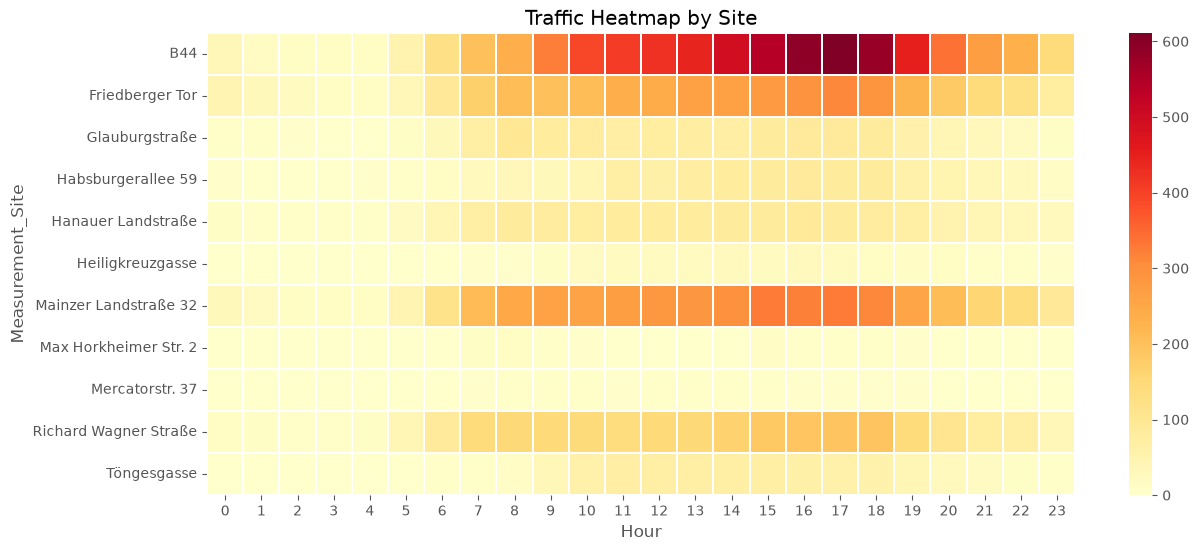

In [13]:
plt.figure(figsize=(14,6))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=0.3

)

plt.title("Traffic Heatmap by Site")

plt.show()

In [14]:
site_stats = (

    df

    .groupby("Measurement_Site")

    ["Total_Traffic"]

    .agg(

        [

            "sum",

            "mean",

            "max",

            "min",

            "std"

        ]

    )

    .round(2)

)

site_stats

,sum,mean,max,min,std
Measurement_Site,,,,,
B44,557154.0,290.18,2292.0,0.0,563.00
Friedberger Tor,350811.0,166.10,1199.0,0.0,314.76
Glauburgstraße,105174.0,49.80,465.0,0.0,99.96
Habsburgerallee 59,78837.0,41.06,330.0,0.0,81.43
Hanauer Landstraße,228414.0,54.08,513.0,0.0,109.41
Heiligkreuzgasse,21417.0,11.15,114.0,0.0,24.37
Mainzer Landstraße 32,361342.0,188.20,1788.0,0.0,400.21
Max Horkheimer Str. 2,5940.0,3.44,210.0,0.0,17.17
Mercatorstr. 37,5352.0,3.10,54.0,0.0,8.23


In [15]:
ranking = site_stats.sort_values(

    "sum",

    ascending=False

)

ranking

,sum,mean,max,min,std
Measurement_Site,,,,,
B44,557154.0,290.18,2292.0,0.0,563.00
Mainzer Landstraße 32,361342.0,188.20,1788.0,0.0,400.21
Friedberger Tor,350811.0,166.10,1199.0,0.0,314.76
Hanauer Landstraße,228414.0,54.08,513.0,0.0,109.41
Richard Wagner Straße,185420.0,107.30,932.0,0.0,228.06
Glauburgstraße,105174.0,49.80,465.0,0.0,99.96
Habsburgerallee 59,78837.0,41.06,330.0,0.0,81.43
Töngesgasse,67545.0,31.98,330.0,0.0,73.83
Heiligkreuzgasse,21417.0,11.15,114.0,0.0,24.37


In [16]:
most_congested = ranking.index[0]

highest_traffic = ranking.iloc[0]["sum"]

print("="*60)

print("Most Congested Site")

print("="*60)

print(f"Site : {most_congested}")

print(f"Total Traffic : {highest_traffic}")

Most Congested Site
Site : B44
Total Traffic : 557154.0


In [17]:
REPORT_DIR = PROJECT_DIR / "reports"

REPORT_DIR.mkdir(exist_ok=True)

site_stats.to_csv(

    REPORT_DIR / "measurement_site_statistics.csv"

)

ranking.to_csv(

    REPORT_DIR / "site_ranking.csv"

)

print("Results Saved Successfully!")

Results Saved Successfully!
